# Low-Rank Structure in Gaussian Covariances

This notebook explores how low-rank changes in Gaussian coefficient matrices affect covariance structure.
The emphasis is on empirical covariance, eigenvalues, and matrix rank.

## Background

$$
x = W z + \varepsilon,\quad z \sim \mathcal{N}(0, I_k),\quad \varepsilon \sim \mathcal{N}(0, \sigma^2 I_d)
$$

$$
\Sigma = W W^\top + \sigma^2 I_d.
$$

In [173]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import eigvalsh

rng = np.random.default_rng(0)

In [174]:
d = 40
k = 8
sigma = 0.1
n = 1500

W0 = rng.normal(size=(d, k))
Sigma0 = W0 @ W0.T + sigma**2 * np.eye(d)

## Low-Rank vs Diffuse Coefficient Changes

In [175]:
rank_star = 2

B = rng.normal(size=(d, rank_star))
A = rng.normal(size=(rank_star, k))
DeltaW_lr = B @ A

D = rng.normal(size=(d, k))
DeltaW_dense = D / np.linalg.norm(D, 'fro') * np.linalg.norm(DeltaW_lr, 'fro')

In [176]:
def sample(W):
    z = rng.normal(size=(n, k))
    eps = sigma * rng.normal(size=(n, d))
    return z @ W.T + eps

'''   
    Previous code :
    
    S_lr = (sample(W0 + DeltaW_lr).T @ sample(W0 + DeltaW_lr)) / n
    S_dense = (sample(W0 + DeltaW_dense).T @ sample(W0 + DeltaW_dense)) / n

    Lead to inaccurate plots and confusing results.  After a lot of research it seems that the code should be:

    lr_sample = sample(W0 + DeltaW_lr)
    dense_sample = sample(W0 + DeltaW_dense)

    S_lr = (lr_sample.T @ lr_sample) / n
    S_dense = (dense_sample.T @ dense_sample) / n

    The first samples twice per numerator, resulting in XiXi transpose using two different values for Xi and Xi.  Two calls to sample() so two draws.  
    We want a single Xi.

'''

lr_sample = sample(W0 + DeltaW_lr)
dense_sample = sample(W0 + DeltaW_dense)

S_lr = (lr_sample.T @ lr_sample) / n
S_dense = (dense_sample.T @ dense_sample) / n

## <b>Eigenvalue analysis</b>
In this section, you will explicitly measure how different coefficient changes affect the spectrum of a Gaussian covariance matrix.
​


### <b>Step 1: Compute eigenvalues</b>
    For each of the following covariance matrices:

        The reference covariance.
    
        The empirical covariance from the low-rank modification. 

        The empirical covariance from the diffuse modification. 

    ​
    
    Compute all eigenvalues and sort them in decreasing order.

In [ ]:
# Compute all eigenvalues and sort them in decreasing order.

eig0 = np.sort(eigvalsh(Sigma0))[::-1]
eig_lr = np.sort(eigvalsh(S_lr))[::-1]
eig_dense = np.sort(eigvalsh(S_dense))[::-1]

print(f"Egenvalues Sorted in Descending:\n\n\t Basseline:\n\t{eig0}\n\n\tLow-Rank\n\t{eig_lr}\n\n\tDense Case\n\t{eig_dense}")

Egenvalues Sorted in Descending:

	 Basseline:
	[8.12904989e+01 6.08975763e+01 5.53590309e+01 3.65448251e+01
 3.23855431e+01 2.74706222e+01 2.13097745e+01 1.91941980e+01
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02
 1.00000000e-02 1.00000000e-02 1.00000000e-02 1.00000000e-02]

	Low-Rank
	[4.30039174e+02 3.90421774e+02 7.10332740e+01 5.97109193e+01
 3.33562500e+01 2.98215196e+01 1.99861836e+01 1.74809418e+01
 1.26475331e-02 1.24047578e-02 1.23432727e-02 1.17905554e-02
 1.16660528e-02 1.12823255e-02 1.11877978e-02 1.10384656e-02
 1.09757327e-02 1.08913883e-02 1.08044227e-02 1.05888108e-02
 1.05153246e-02 1.030910


###  Step 2: Visualize the spectra
Create a single plot that shows:
    
    The eigenvalues of reference covariance.

    The eigenvalues of empirical covariance from Low-Rank.

    The eigenvalues of empirical covariance from Dense Case.
 
on the same axes.
Use a logarithmic scale on the vertical axis.
This plot should allow you to visually compare:
how many eigenvalues are significantly larger than the noise floor,
and how the different modifications affect the spectrum.

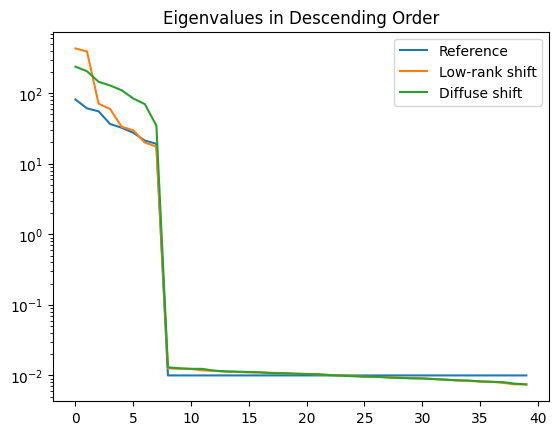

In [178]:

plt.title("Eigenvalues in Descending Order")
plt.semilogy(eig0, label='Reference')
plt.semilogy(eig_lr, label='Low-rank shift')
plt.semilogy(eig_dense, label='Diffuse shift')
plt.legend()
plt.show()


### <b>Step 3: Quantify “significant change”</b>
Define an eigenvalue as significantly changed if it differs from the corresponding eigenvalue of the Reference Covariance Matrix ​
  by more than a fixed threshold (e.g., 10% relative difference).

Using this criterion:

    Count how many eigenvalues change significantly in the low-rank case.

    Count how many eigenvalues change significantly in the diffuse case.

Report these numbers explicitly.

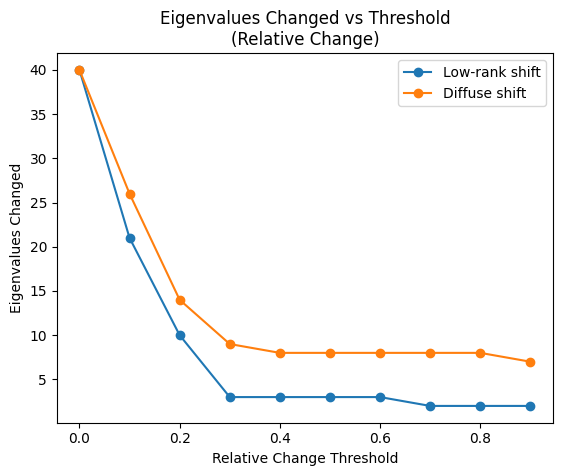

In [179]:
'''
    Relative change formula:  Rel_Change = abs( eigen_new - eigen_old) / abs(eigen_old))
'''

# Plot eigenvalues changed per threshold.
eigen_lr_count = []
eigen_dense_count = []
eigen_thresholds = []


# Run range of thresholds to find reasonable one.
for eig_thresh  in range(0,10,1):

    # Scale threshold.
    eig_thresh = eig_thresh * 0.1

    # Find significant change by list comprehension.
    eig_sig_lr = ((abs(eig_lr - eig0)) / abs(eig0) > eig_thresh).sum()
    eig_sig_dense = ((abs(eig_dense - eig0)) / abs(eig0) > eig_thresh).sum()

    # Store results for plotting.
    eigen_thresholds.append(eig_thresh)
    eigen_lr_count.append(eig_sig_lr)
    eigen_dense_count.append(eig_sig_dense)


# Plot eigen counts per threshold.
plt.title("Eigenvalues Changed vs Threshold\n(Relative Change)")
plt.xlabel("Relative Change Threshold")
plt.ylabel("Eigenvalues Changed")

plt.plot(eigen_thresholds, eigen_lr_count, marker='o', label='Low-rank shift')
plt.plot(eigen_thresholds, eigen_dense_count, marker='o', label='Diffuse shift')

plt.legend()
plt.show()


In [180]:
# Set threshold to 20% relative change per plot above.

eign_threshold = 0.2

# Find significant change by list comprehension.
sig_eign_lr = ((abs(eig_lr - eig0)) / abs(eig0) > eign_threshold).sum()
sig_eign_dense = ((abs(eig_dense - eig0)) / abs(eig0) > eign_threshold).sum()

print("\n\n")
print(f"There are {sig_eign_lr} eigenvalues that changed significantly in the Low-Rank Matrix.  Threshold from baseline: {eign_threshold * 100:.1f}%")
print(f"There are {sig_eign_dense} eigenvalues that changed significantly in the Diffuse Matrix.  Threshold from baseline: {eign_threshold * 100:.1f}%")





There are 10 eigenvalues that changed significantly in the Low-Rank Matrix.  Threshold from baseline: 20.0%
There are 14 eigenvalues that changed significantly in the Diffuse Matrix.  Threshold from baseline: 20.0%


### <b>Step 4: Interpret the results </b>

Answer the following questions in complete sentences:

    1. In the low-rank case, how many eigenvalues change substantially, and how does this number relate to the rank of the coefficient modification?

    2. In the diffuse case, why are many eigenvalues affected, even though the overall magnitude of the change is the same?

    3. How do these observations illustrate the idea that matrix rank limits the number of variance directions that can change?
    

Your explanation should explicitly reference:
    eigenvalues,
    rank,
    and geometric directions of variance.

In [188]:
# Calculate the rank of the Coefficient Modifications. 
# Create new covariance matrices.



W_lr = W0 + DeltaW_lr
W_dense = W0 + DeltaW_dense

Sigma_lr = W_lr @ W_lr.T + sigma**2 * np.eye(d)
Sigma_dense = W_dense @ W_dense.T + sigma**2 * np.eye(d)

# Calculate Sigma Low Rank.
# Calculate Sigma Dense Case.

rank_lr = np.linalg.matrix_rank(Sigma_lr - Sigma0)
rank_dense = np.linalg.matrix_rank(Sigma_dense - Sigma0)

print(f"The rank of the Coefficient Modification for:\n\n\tSigma0:  None.  This is our reference baseline.\n\n\tLow-Rank: {rank_lr}\n\n\tDense Case: {rank_dense}")



The rank of the Coefficient Modification for:

	Sigma0:  None.  This is our reference baseline.

	Low-Rank: 4

	Dense Case: 16


1) In the Low-Rank case 10 eigenvalues changed significantly by 20% or more.  The Low-Rank transform has a rank of the new Low-Rank Matrix after Coefficient Change is 4.  Compared the the Dense Case this rank is lower, and the number of eigenvalues is also lower in the Low-Rank compared to the Dense Case.

2)  In the Dense Case there are 14 eigenvalues which changed significantly by 20% or more.  More eigenvalues changed even though the overall magnitude of the change is the same because the Dense Case is of higher rank than the Low Rank case.  This is not just in the name.  The Low Rank case has more interdependent columns or rows (that's what makes it low rank).  Therefore the weight changes will sort of ripple through the matrix and affect fewer eigenvalues overall because each change is affecting interdependent eigenvalues.  So there is overlap between the eigenvalues changed, and therefore we see fewer overall individual changes.  This is like changing 5 things 4 times vs 20 things once.  We have made 20 changes in each case, but we have more single things changed in one case than the other.

3)  This illustrates that Matrix Rank limits the number of variance directions that can change in the sense that those directions are related to the eigenvectors of the matrix, and therefore the eigenvalues.  With fewer eigenvalues to change in a low rank vs. full (or near full) rank case we commensurately have fewer eigenvectors available to alter.  These vectors correspond to the variance directions available to alter.